# Directed Evolution loop — V1

First simple test of `sequence_classesV1.py` (`Protocol`, `Lambda`) and `analysisV1.py`
(the 8 plotting/analysis functions), on a small toy library.

Pipeline for one round of `Protocol.loop_DE()`:

$$
\lambda_0 \xrightarrow{\text{NGS}} \lambda_0' \qquad
\lambda_0 \xrightarrow{\text{sampling}} \lambda_1 \xrightarrow{\text{produce\_capsids}} \lambda_2 \xrightarrow{\text{NGS}} \lambda_2' \qquad
\lambda_2 \xrightarrow{\text{selectivty}} \lambda_3 \xrightarrow{\text{NGS}} \lambda_3' \qquad
\lambda_3 \xrightarrow{\text{bacterial\_amplification}} \lambda_4
$$

`lambda0/1/2/3/4` = true pools (biological chain). `lambda0p/2p/3p` = NGS read-count
snapshots (side channel, Negative Binomial, never fed back into the chain).


## 0. Protocol parameters

Fixed constants from `sequence_classesV1.py`, used as defaults throughout `Protocol` unless overridden at construction time.

In [2]:
import sequence_classesV1
print(sequence_classesV1.__file__)
print(sequence_classesV1.message)

/Users/merlincc/Library/Mobile Documents/com~apple~CloudDocs/IDV AAV/Directed-Evolution-loop/Modelization_V1/sequence_classesV1.py
file 2.1


In [3]:
import analysisV1
print(analysisV1.__file__)
print(analysisV1.message)

/Users/merlincc/Library/Mobile Documents/com~apple~CloudDocs/IDV AAV/Directed-Evolution-loop/Modelization_V1/analysisV1.py
file analysis 2.3


In [4]:
import RegressionV1 as reg
print(reg.message)

file regression 1.0


In [5]:
import pandas as pd
from sequence_classesV1 import rho, alpha, epsilon, T_sel, T_viab, M, K_MM, K_MM_amp, D, N1, phi

params = pd.DataFrame([
    ("rho",     rho,     "HEK cells transfected per plasmid"),
    ("alpha",   alpha,   "capsid yield per transfected cell"),
    ("epsilon", epsilon, "per-cell production noise amplitude"),
    ("T_sel",   T_sel,   "selectivity temperature"),
    ("T_viab",  T_viab,  "viability temperature (larger = more uniform production)"),
    ("M",       M,       "number of PCR amplification cycles"),
    ("K_MM",    K_MM,    "Michaelis-Menten saturation constant for PCR"),
    ("K_MM_amp",K_MM_amp,"same as before"),
    ("D",       D,       "sequencing depth (reads per NGS readout)"),
    ("N1",      N1,      "number of plasmids sampled for transfection"),
    ("phi",     phi,     "NB dispersion for sequencing reads (smaller phi = closer to Poisson)"),
], columns=["Parameter", "Value", "Description"])

params

,Parameter,Value,Description
0,rho,1.000000e-03,HEK cells transfected per plasmid
1,alpha,4.000000e+03,capsid yield per transfected cell
2,epsilon,1.000000e-02,per-cell production noise amplitude
3,T_sel,5.000000e-01,selectivity temperature
4,T_viab,5.000000e-01,viability temperature (larger = more uniform p...
5,M,4.000000e+01,number of PCR amplification cycles
6,K_MM,1.000000e+06,Michaelis-Menten saturation constant for PCR
7,K_MM_amp,1.000000e+08,same as before
8,D,1.000000e+10,sequencing depth (reads per NGS readout)
9,N1,1.000000e+07,number of plasmids sampled for transfection


In [6]:
names            = ["lambda0", "lambda1", "lambda2", "lambda3", "lambda4"]
namesp           = ["lambda0p", "lambda2p", "lambda3p"]

pct_thresholds = [1, 0.1, 0.01, 0.001, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 0]
pct_thresholds_p = [1e-4, 8*1e-5, 6*1e-5, 5.5*1e-5, 5*1e-5, 4.5*1e-5, 4*1e-5, 2*1e-5, 1e-5]

## 1. Imports

In [7]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from sequence_classesV1 import *
from analysisV1 import *

## 2. Toy library and ground-truth (Teacher) Potts model

Small library so the whole notebook runs in seconds. `F_viab`/`F_sel` are dense
random profile matrices; `J_viab`/`J_sel` are *sparse* (only a handful of nonzero
pairwise couplings each) — a dense random `J` blows up `exp(score/T)` in
`produce_capsids` since it sums scores over every transfected cell.

In [8]:
key = jax.random.key(0)
key, k_seq, k_Fv, k_Fs, k_Jv, k_Js = jax.random.split(key, 6)

num_sequences   = 800000
L               = 7     # sequence length
A               = 20    # amino-acid alphabet size

sequences = jax.random.randint(k_seq, shape=(num_sequences, L), minval=0, maxval=A)

F_viab, F_sel, J_viab, J_sel  = initialize_random_weights(key=key)

print(f"Library: {num_sequences} sequences of length {L}")
print(f"F_viab shape: {F_viab.shape}, J_viab nonzero entries: {int(jnp.sum(J_viab != 0))}")

Library: 800000 sequences of length 7
F_viab shape: (20, 7), J_viab nonzero entries: 16800


Sanity check with `plot_teacher_weights` (function 1 from `analysisV1.py`):

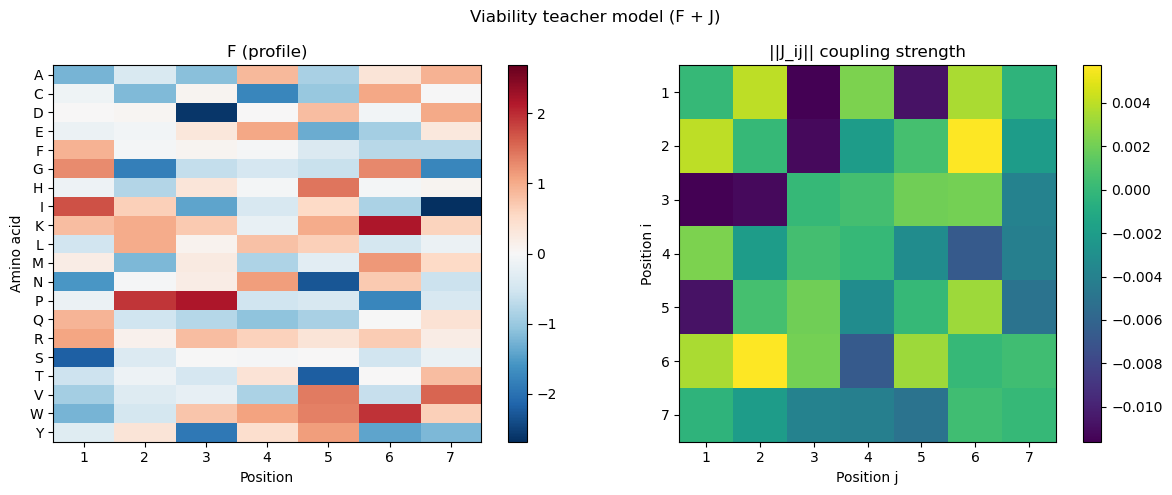

In [9]:
_ = plot_teacher_weights(F_viab, J_viab, title="Viability teacher model (F + J)")
plt.show()

## 3. Build the `Protocol`

`Protocol` wraps the whole simulation: `sequence` (identity, `(d0, 7)`, constant) and
`lambda0..lambda4` / `lambda0p,2p,3p` (abundance pools, all `(d0,)`, evolve each round).

In [10]:
protocol = ProtocolV2(
    N0=100_000_000, N1=N1, dilution_factor=10, sequences=sequences, D=D,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

print("protocol.sequence shape:", protocol.sequence.shape, "  (identity, never changes)")
print("protocol.model     :", protocol.model)
print()
print("Lambda shapes right after construction (should all be (d0,) = (%d,)):" % protocol.d0)
for name in ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]:
    print(f"  {name:10s} : {getattr(protocol, name).shape}")

protocol.sequence shape: (800000, 7)   (identity, never changes)
protocol.model     : Potts

Lambda shapes right after construction (should all be (d0,) = (800000,)):
  lambda0    : (800000,)
  lambda0p   : (800000,)
  lambda1    : (800000,)
  lambda2    : (800000,)
  lambda2p   : (800000,)
  lambda3    : (800000,)
  lambda3p   : (800000,)
  lambda4    : (800000,)


Initial library, colored by viability/selectivity score (function 2):

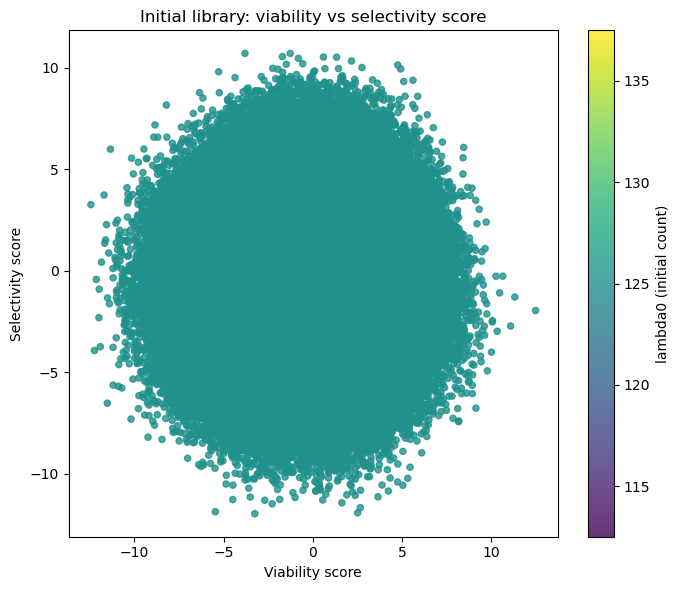

In [8]:
_ = plot_initial_library_scores(protocol)
plt.show()

## 4. Run one round of `loop_DE()`

In [9]:
bio_row, ngs_row = protocol.loop_DE()
lambda0, lambda1, lambda2, lambda3, lambda4 = bio_row
lambda0p, lambda2p, lambda3p = ngs_row

print("After loop_DE():")
for label, arr in [("lambda0", lambda0), ("lambda1", lambda1), ("lambda2", lambda2),
                    ("lambda3", lambda3), ("lambda4", lambda4),
                    ("lambda0p", lambda0p), ("lambda2p", lambda2p), ("lambda3p", lambda3p)]:
    arr = np.array(arr)
    print(f"  {label:10s} total={arr.sum():>14,.0f}  non-zero={(arr > 0).sum():>4d} / {protocol.d0}")

After loop_DE():
  lambda0    total=   100,000,000  non-zero=800000 / 800000
  lambda1    total=     9,998,129  non-zero=799997 / 800000
  lambda2    total=123,521,843,200  non-zero=9145 / 800000
  lambda3    total=43,054,538,752  non-zero=7981 / 800000
  lambda4    total=   100,000,712  non-zero=4732 / 800000
  lambda0p   total= 9,995,731,229  non-zero=799999 / 800000
  lambda2p   total= 9,684,674,931  non-zero=8118 / 800000
  lambda3p   total= 9,410,763,583  non-zero=6876 / 800000


Counts through viability + selectivity (function 3):

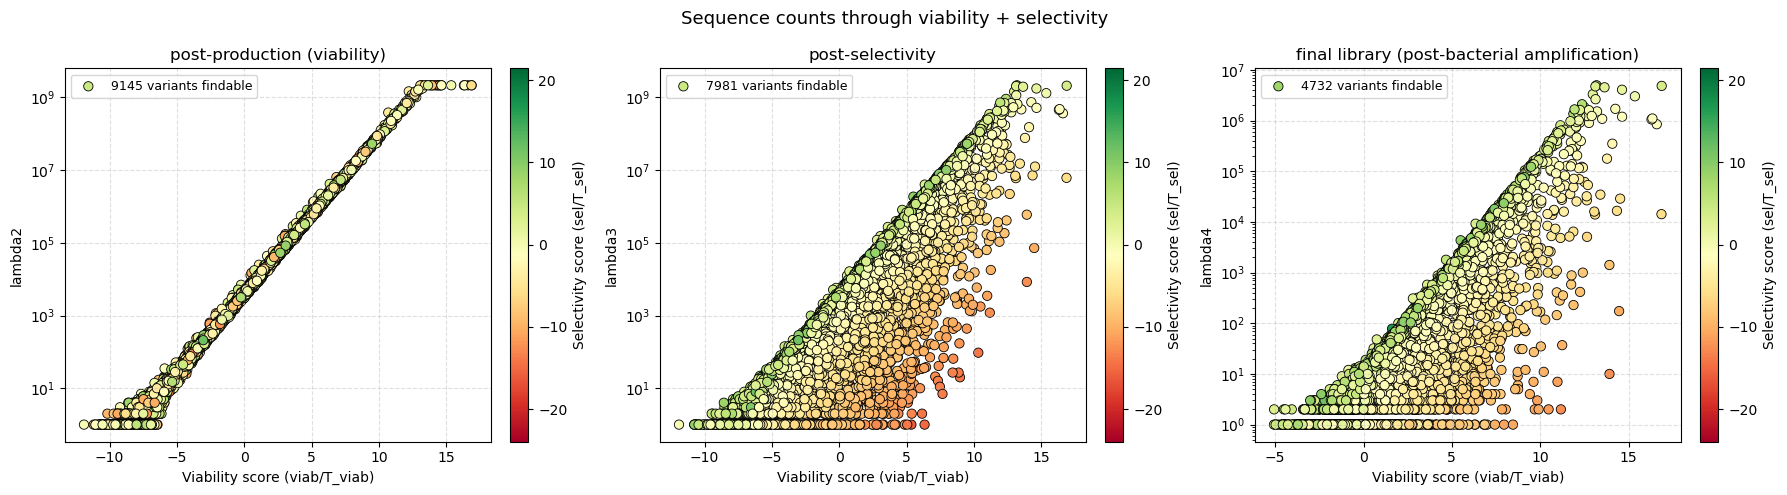

In [10]:
_ = plot_counts_after_selection(protocol)
plt.show()

All 8 lambdas of that same round on one plot (function 8):

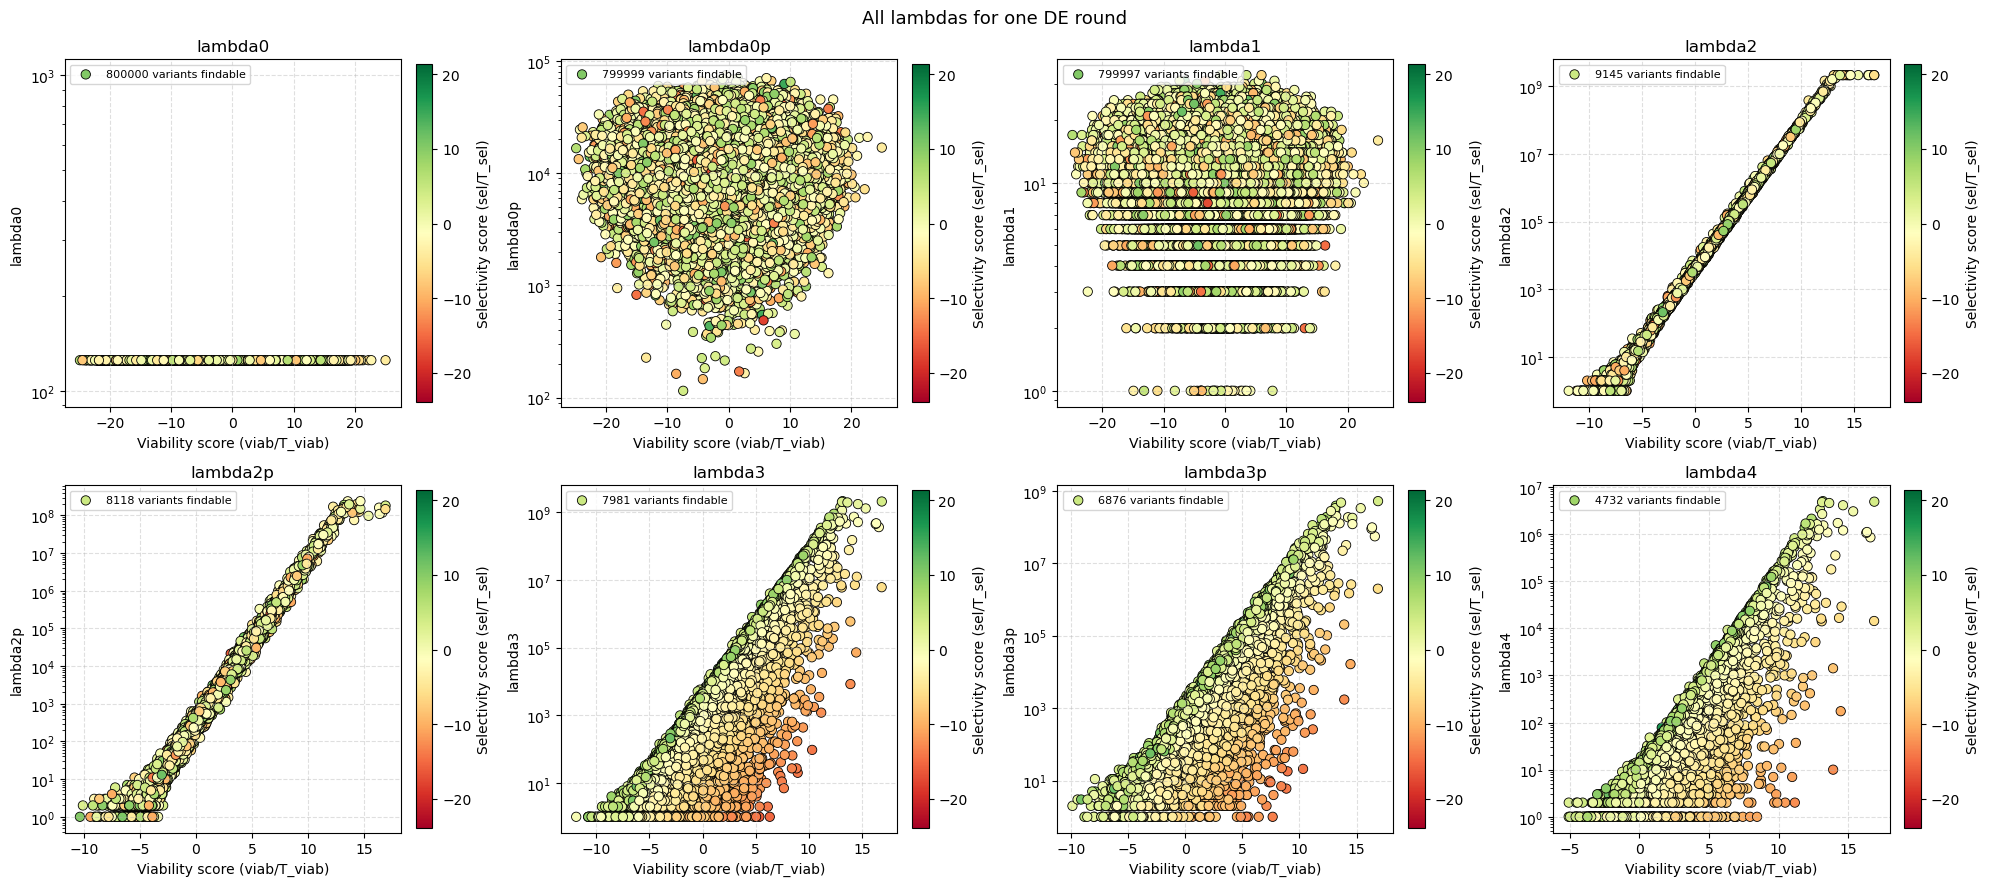

In [11]:
_ = plot_loop_lambdas(protocol, run_loop=False)  # reuse the round we just ran
plt.show()

## 5. Run several rounds with `N_loop_DE` and track library evolution

In [12]:
"""protocol_multi = ProtocolV2(
    N0=100_000_000, N1=10_000_000, sequences=sequences, 
    D=D, F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, 
    J_sel=J_sel, noise_viab=0.01, noise_sel=0.01,
)

fig, rounds = plot_library_evolution(protocol_multi, N=5, threshold=500)
plt.show()

print(f"N_loop_DE returned {len(rounds)} rounds")"""

'protocol_multi = ProtocolV2(\n    N0=100_000_000, N1=10_000_000, sequences=sequences, \n    D=D, F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, \n    J_sel=J_sel, noise_viab=0.01, noise_sel=0.01,\n)\n\nfig, rounds = plot_library_evolution(protocol_multi, N=5, threshold=500)\nplt.show()\n\nprint(f"N_loop_DE returned {len(rounds)} rounds")'

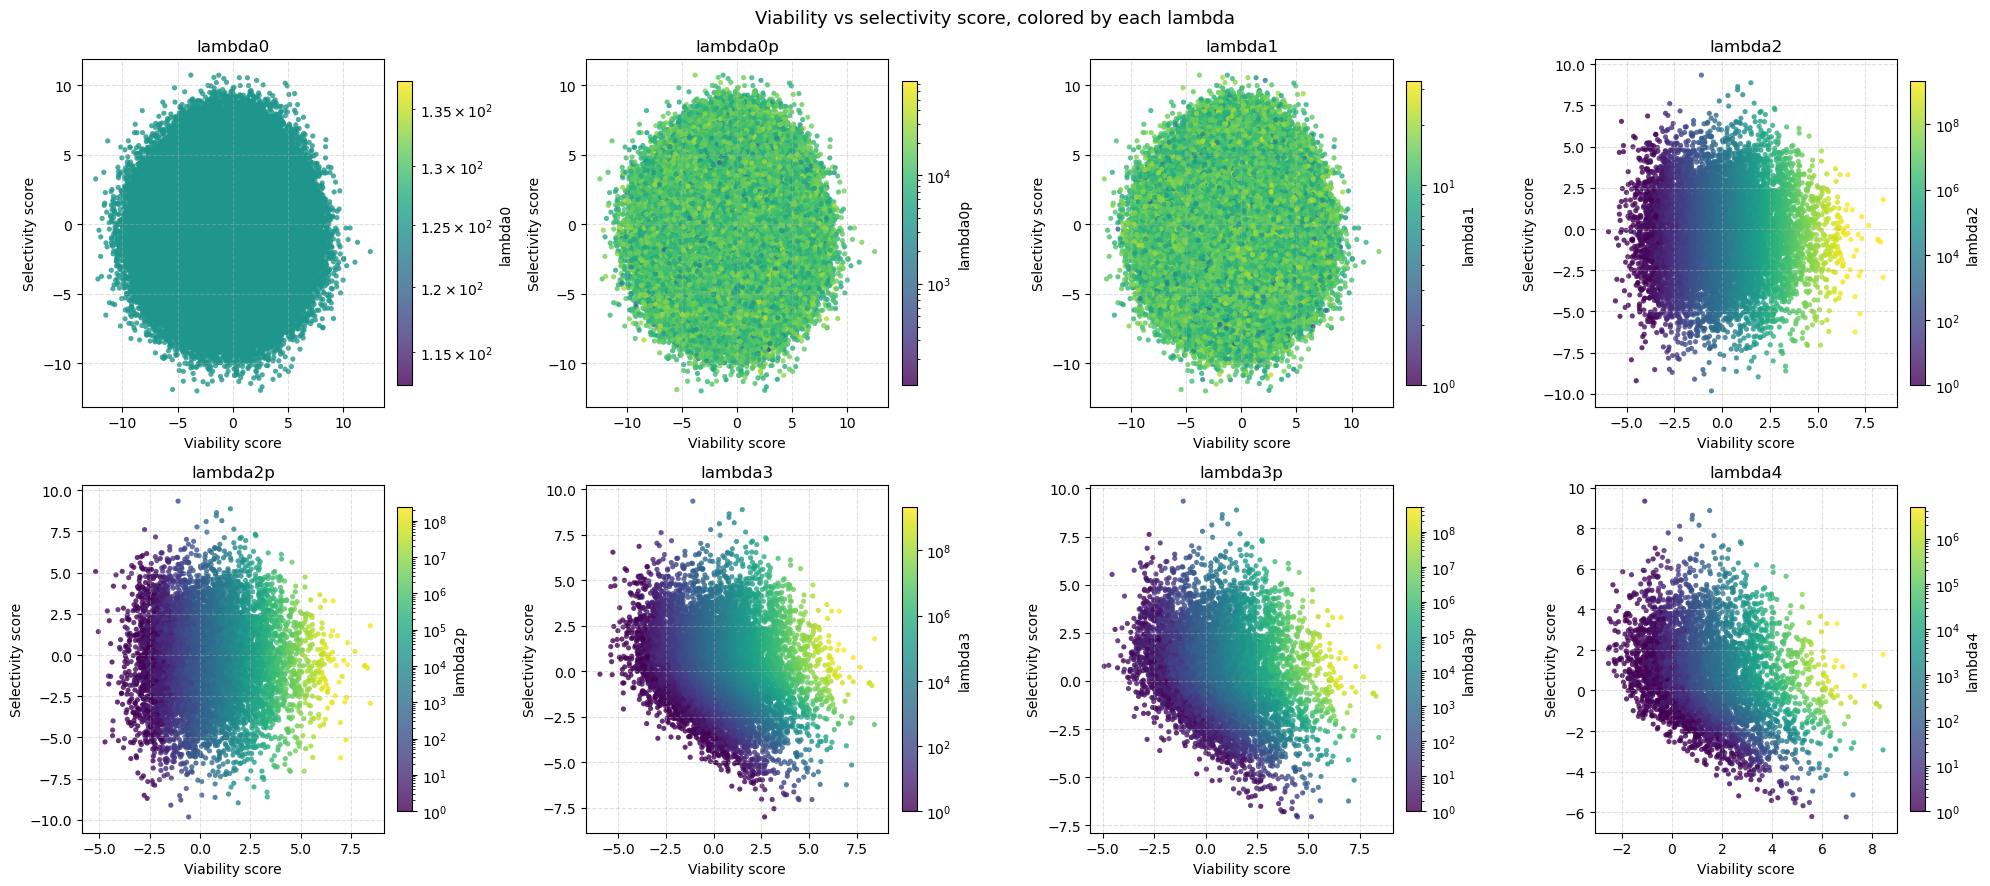

In [13]:
_ = plot_all_lambda_scores(protocol)
plt.show()

## Test 1 : Value of F, the factor of dilution

Whatever the value of D, a large part of sequences disappear in the NGS. Lets see how many sequences we have over some threshold.

In [8]:
threshold_values = [10e0, 10e1, 10e2, 10e3, 10e4, 10e5]
lambdas          = [lambda0, lambda1, lambda2, lambda3, lambda4]
names            = ["lambda0", "lambda1", "lambda2", "lambda3", "lambda4"]

number_of_seq_threshold(lambdas=lambdas, thresholds=threshold_values, names=names)

NameError: name 'lambda0' is not defined

In [ ]:
lambdaps         = [lambda0p, lambda2p, lambda3p]
namesp           = ["lambda0p", "lambda2p", "lambda3p"]
number_of_seq_threshold(lambdas=lambdaps, thresholds=threshold_values, names=namesp)

,10.0,100.0,1000.0,10000.0,100000.0,1000000.0
lambda,,,,,,
lambda0p,799999,799999,799737,479424,0,0
lambda2p,6835,5206,3504,1995,975,395
lambda3p,5882,4426,2933,1717,846,333


Relative proportions (`proportion_above_threshold` from `analysisV1.py`): how many sequences are abundant -- present above a given percentage of the pool total -- for the biological chain and the NGS reads separately.

In [ ]:
pct_thresholds = [1, 0.1, 0.01, 0.001, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 0]

proportion_above_threshold(lambdas=lambdas, thresholds_pct=pct_thresholds, names=names)

,> 1%,> 0.1%,> 0.01%,> 0.001%,> 0.0001%,> 1e-05%,> 1e-06%,> 1e-07%,> 1e-08%,> 1e-09%,> 0%
lambda,,,,,,,,,,,
lambda0,0,0,0,0,800000,800000,800000,800000,800000,800000,800000
lambda1,0,0,0,0,638633,799997,799997,799997,799997,799997,799997
lambda2,32,145,388,1003,2035,3541,5274,6853,8128,8895,9145
lambda3,29,123,337,844,1721,2942,4465,5858,7117,7981,7981
lambda4,29,123,338,846,1722,2918,4169,4732,4732,4732,4732


In [ ]:
pct_thresholds_p = [1e-4, 8*1e-5, 6*1e-5, 5.5*1e-5, 5*1e-5, 4.5*1e-5, 4*1e-5, 2*1e-5, 1e-5]

proportion_above_threshold(lambdas=lambdas, thresholds_pct=pct_thresholds_p, names=names)

,> 0.0001%,> 8e-05%,> 6e-05%,> 5.5e-05%,> 5e-05%,> 4.5e-05%,> 4e-05%,> 2e-05%,> 1e-05%
lambda,,,,,,,,,
lambda0,800000,800000,800000,800000,800000,800000,800000,800000,800000
lambda1,638633,744222,788131,788131,795799,795799,798772,799963,799997
lambda2,2035,2180,2346,2406,2462,2531,2591,3043,3541
lambda3,1721,1822,1968,2011,2054,2109,2177,2524,2942
lambda4,1722,1812,1970,2006,2050,2107,2171,2524,2918


In [ ]:
proportion_above_threshold(lambdas=lambdaps, thresholds_pct=pct_thresholds, names=namesp)

,> 1%,> 0.1%,> 0.01%,> 0.001%,> 0.0001%,> 1e-05%,> 1e-06%,> 1e-07%,> 1e-08%,> 1e-09%,> 0%
lambda,,,,,,,,,,,
lambda0p,0,0,0,0,479643,799737,799999,799999,799999,799999,799999
lambda2p,33,147,400,989,2015,3529,5231,6835,8118,8118,8118
lambda3p,32,119,343,860,1746,2963,4448,5882,6876,6876,6876


The factor of dilution can help signicantly to get rid of variants that are not the optimal variants. The effect on noise should be analyse for further conclusion.

In [8]:
protocol = ProtocolV2(
    N0=100_000_000, N1=N1, dilution_factor=1000, sequences=sequences, D=D,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

print("protocol.sequence shape:", protocol.sequence.shape, "  (identity, never changes)")
print("protocol.model     :", protocol.model)
print()
print("Lambda shapes right after construction (should all be (d0,) = (%d,)):" % protocol.d0)
for name in ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]:
    print(f"  {name:10s} : {getattr(protocol, name).shape}")

protocol.sequence shape: (800000, 7)   (identity, never changes)
protocol.model     : Potts

Lambda shapes right after construction (should all be (d0,) = (800000,)):
  lambda0    : (800000,)
  lambda0p   : (800000,)
  lambda1    : (800000,)
  lambda2    : (800000,)
  lambda2p   : (800000,)
  lambda3    : (800000,)
  lambda3p   : (800000,)
  lambda4    : (800000,)


In [9]:
new_bio_row, new_ngs_row = protocol.loop_DE()
new_lambda0, new_lambda1, new_lambda2, new_lambda3, new_lambda4 = new_bio_row
new_lambda0p, new_lambda2p, new_lambda3p = new_ngs_row

print("After loop_DE():")
for label, arr in [("lambda0", new_lambda0), ("lambda1", new_lambda1), ("lambda2", new_lambda2),
                    ("lambda3", new_lambda3), ("lambda4", new_lambda4),
                    ("lambda0p", new_lambda0p), ("lambda2p", new_lambda2p), ("lambda3p", new_lambda3p)]:
    arr = np.array(arr)
    print(f"  {label:10s} total={arr.sum():>14,.0f}  non-zero={(arr > 0).sum():>4d} / {protocol.d0}")
    
new_lambdaps         = [new_lambda0p, new_lambda2p, new_lambda3p]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

After loop_DE():
  lambda0    total=   100,000,000  non-zero=800000 / 800000
  lambda1    total=     9,998,129  non-zero=799997 / 800000
  lambda2    total=123,521,843,200  non-zero=9145 / 800000
  lambda3    total=43,054,538,752  non-zero=7981 / 800000
  lambda4    total=   100,000,712  non-zero=4732 / 800000
  lambda0p   total=10,004,205,649  non-zero=94093 / 800000
  lambda2p   total= 9,684,900,069  non-zero=5810 / 800000
  lambda3p   total= 9,410,328,057  non-zero=4270 / 800000


In [10]:
proportion_above_threshold(lambdas=new_lambdaps, thresholds_pct=pct_thresholds, names=namesp)

,> 1%,> 0.1%,> 0.01%,> 0.001%,> 0.0001%,> 1e-05%,> 1e-06%,> 1e-07%,> 1e-08%,> 1e-09%,> 0%
lambda,,,,,,,,,,,
lambda0p,0,0,0,38815,89670,93811,94092,94093,94093,94093,94093
lambda2p,33,147,400,990,2014,3545,5198,5810,5810,5810,5810
lambda3p,32,120,341,858,1735,2985,4188,4270,4270,4270,4270


Visualizing which variants disappear as dilution increases: every variant found in `lambda3p` is plotted (x = viability score, y = selectivity score), once per `dilution_factor`, layered from red (weak dilution, most variants present) up to blue (strong dilution, drawn last/on top). A point that stays visibly red was lost once dilution increased; a point that ends up blue survived even the strongest dilution tested -- this lets us check directly whether attrition is uniform across score-space or concentrated on low-score (inefficient, lower-abundance) variants. Note the inclusion is only approximate (~97-99.8% overlap between consecutive levels), since each `dilution_factor` redraws independent randomness rather than sub-sampling the previous draw.

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

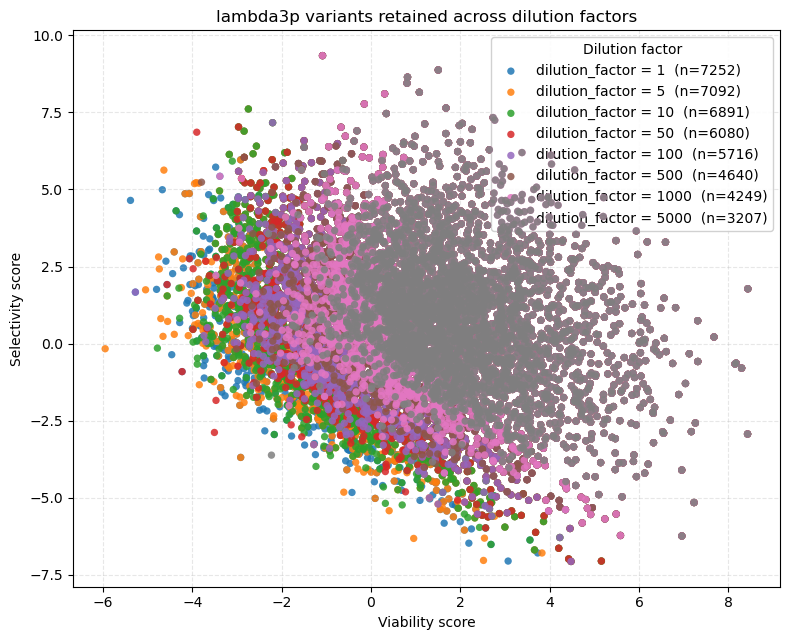

In [11]:
dilution_factors_test = [1, 5, 10, 50, 100, 500, 1000, 5000]
fig = plot_lambda3p_dilution_scatter(protocol, dilution_factors_test)
plt.show()

### Let's add some noise to see how dilution affects the results.

protocol.sequence shape: (800000, 7)   (identity, never changes)
protocol.model     : Potts

Lambda shapes right after construction (should all be (d0,) = (800000,)):
  lambda0    : (800000,)
  lambda0p   : (800000,)
  lambda1    : (800000,)
  lambda2    : (800000,)
  lambda2p   : (800000,)
  lambda3    : (800000,)
  lambda3p   : (800000,)
  lambda4    : (800000,)


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

After loop_DE():
  lambda0    total=   100,000,000  non-zero=800000 / 800000
  lambda1    total=     9,998,129  non-zero=799997 / 800000
  lambda2    total=463,616,442,368  non-zero=8661 / 800000
  lambda3    total=207,584,198,656  non-zero=7594 / 800000
  lambda4    total=    99,999,104  non-zero=3883 / 800000
  lambda0p   total= 9,995,731,229  non-zero=799999 / 800000
  lambda2p   total=10,070,846,717  non-zero=7140 / 800000
  lambda3p   total= 9,859,190,775  non-zero=6177 / 800000


...

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

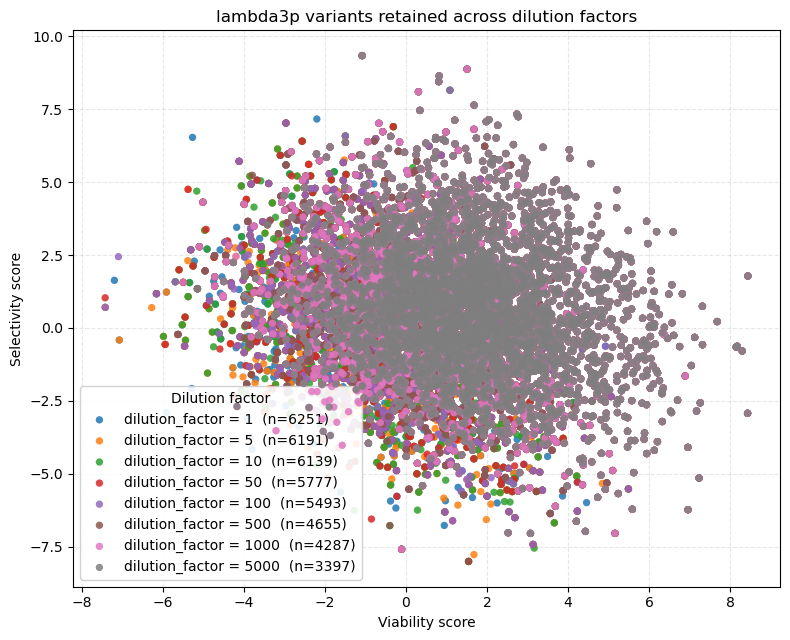

In [12]:
protocol = ProtocolV2(
    N0=100_000_000, N1=N1, dilution_factor=10, sequences=sequences, D=D,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=4, noise_sel=4,
)

print("protocol.sequence shape:", protocol.sequence.shape, "  (identity, never changes)")
print("protocol.model     :", protocol.model)
print()
print("Lambda shapes right after construction (should all be (d0,) = (%d,)):" % protocol.d0)
for name in ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]:
    print(f"  {name:10s} : {getattr(protocol, name).shape}")
    
bio_row, ngs_row = protocol.loop_DE()
lambda0, lambda1, lambda2, lambda3, lambda4 = bio_row
lambda0p, lambda2p, lambda3p = ngs_row

print("After loop_DE():")
for label, arr in [("lambda0", lambda0), ("lambda1", lambda1), ("lambda2", lambda2),
                    ("lambda3", lambda3), ("lambda4", lambda4),
                    ("lambda0p", lambda0p), ("lambda2p", lambda2p), ("lambda3p", lambda3p)]:
    arr = np.array(arr)
    print(f"  {label:10s} total={arr.sum():>14,.0f}  non-zero={(arr > 0).sum():>4d} / {protocol.d0}")
    
dilution_factors_test = [1, 5, 10, 50, 100, 500, 1000, 5000]
fig = plot_lambda3p_dilution_scatter(protocol, dilution_factors_test)
plt.show()

### What happens after multiple rounds (with and without noise)

protocol.sequence shape: (800000, 7)   (identity, never changes)
protocol.model     : Potts

Lambda shapes right after construction (should all be (d0,) = (800000,)):
  lambda0    : (800000,)
  lambda0p   : (800000,)
  lambda1    : (800000,)
  lambda2    : (800000,)
  lambda2p   : (800000,)
  lambda3    : (800000,)
  lambda3p   : (800000,)
  lambda4    : (800000,)


Directed evolution rounds:   0%|          | 0/3 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

...

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

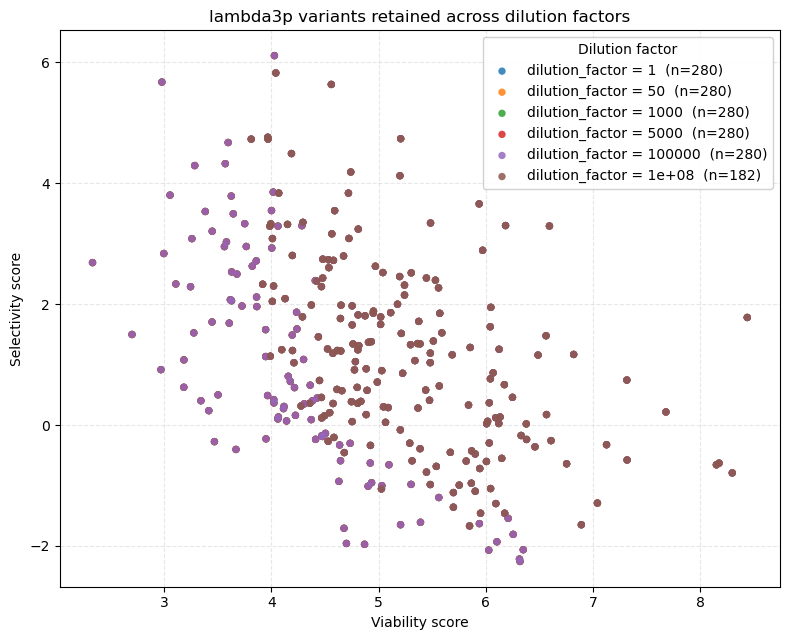

In [13]:
protocol = ProtocolV2(
    N0=100_000_000, N1=N1, dilution_factor=10, sequences=sequences, D=D,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

print("protocol.sequence shape:", protocol.sequence.shape, "  (identity, never changes)")
print("protocol.model     :", protocol.model)
print()
print("Lambda shapes right after construction (should all be (d0,) = (%d,)):" % protocol.d0)
for name in ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]:
    print(f"  {name:10s} : {getattr(protocol, name).shape}")
    
lambdas = protocol.N_loop_DE(3)
last_lambda0, last_lambda1, last_lambda2, last_lambda3, last_lambda4 = lambdas[-1][0]
last_lambda0p, last_lambda2p, last_lambda3p = lambdas[-1][1]

for label, arr in [("lambda0", last_lambda0), ("lambda1", last_lambda1), ("lambda2", last_lambda2),
                    ("lambda3", last_lambda3), ("lambda4", last_lambda4),
                    ("lambda0p", last_lambda0p), ("lambda2p", last_lambda2p), ("lambda3p", last_lambda3p)]:
    arr = np.array(arr)
    print(f"  {label:10s} total={arr.sum():>14,.0f}  non-zero={(arr > 0).sum():>4d} / {protocol.d0}")
    
dilution_factors_test = [1, 50, 1000, 5000, 1e5, 1e8]
fig = plot_lambda3p_dilution_scatter(protocol, dilution_factors_test)
plt.show()


In [14]:
proportion_above_threshold(lambdas=lambdas[-1][0], thresholds_pct=pct_thresholds, names=names)

,> 1%,> 0.1%,> 0.01%,> 0.001%,> 0.0001%,> 1e-05%,> 1e-06%,> 1e-07%,> 1e-08%,> 1e-09%,> 0%
lambda,,,,,,,,,,,
lambda0,46,142,249,401,485,503,508,508,508,508,508
lambda1,46,142,251,400,481,499,503,503,503,503,503
lambda2,0,162,216,268,280,280,280,280,280,280,280
lambda3,45,144,215,268,280,280,280,280,280,280,280
lambda4,45,144,215,268,280,280,280,280,280,280,280


protocol.sequence shape: (800000, 7)   (identity, never changes)
protocol.model     : Potts

Lambda shapes right after construction (should all be (d0,) = (800000,)):
  lambda0    : (800000,)
  lambda0p   : (800000,)
  lambda1    : (800000,)
  lambda2    : (800000,)
  lambda2p   : (800000,)
  lambda3    : (800000,)
  lambda3p   : (800000,)
  lambda4    : (800000,)


Directed evolution rounds:   0%|          | 0/3 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

...

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

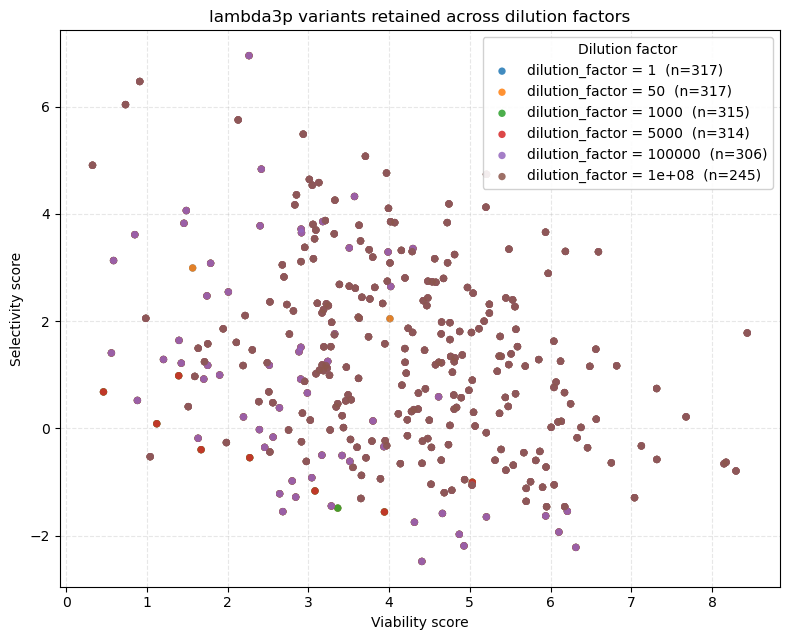

In [15]:
protocol = ProtocolV2(
    N0=100_000_000, N1=N1, dilution_factor=10, sequences=sequences, D=D,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=4, noise_sel=4,
)

print("protocol.sequence shape:", protocol.sequence.shape, "  (identity, never changes)")
print("protocol.model     :", protocol.model)
print()
print("Lambda shapes right after construction (should all be (d0,) = (%d,)):" % protocol.d0)
for name in ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]:
    print(f"  {name:10s} : {getattr(protocol, name).shape}")
    
lambdas = protocol.N_loop_DE(3)
last_lambda0, last_lambda1, last_lambda2, last_lambda3, last_lambda4 = lambdas[-1][0]
last_lambda0p, last_lambda2p, last_lambda3p = lambdas[-1][1]

for label, arr in [("lambda0", last_lambda0), ("lambda1", last_lambda1), ("lambda2", last_lambda2),
                    ("lambda3", last_lambda3), ("lambda4", last_lambda4),
                    ("lambda0p", last_lambda0p), ("lambda2p", last_lambda2p), ("lambda3p", last_lambda3p)]:
    arr = np.array(arr)
    print(f"  {label:10s} total={arr.sum():>14,.0f}  non-zero={(arr > 0).sum():>4d} / {protocol.d0}")
    
dilution_factors_test = [1, 50, 1000, 5000, 1e5, 1e8]
fig = plot_lambda3p_dilution_scatter(protocol, dilution_factors_test)
plt.show()

In [16]:
proportion_above_threshold(lambdas=lambdas[-1][0], thresholds_pct=pct_thresholds, names=names)

,> 1%,> 0.1%,> 0.01%,> 0.001%,> 0.0001%,> 1e-05%,> 1e-06%,> 1e-07%,> 1e-08%,> 1e-09%,> 0%
lambda,,,,,,,,,,,
lambda0,0,210,298,366,414,457,486,500,500,500,500
lambda1,0,210,299,365,413,447,464,464,464,464,464
lambda2,0,238,262,285,298,308,315,316,317,317,318
lambda3,0,212,258,283,294,305,313,315,317,317,317
lambda4,0,212,258,284,295,306,312,313,313,313,313


## 6. Weight recovery test (`RegressionV1.py`) : impact of initial diversity

`RegressionV1.fit_weights_potts` / `ridge_cv_mse_potts` implement standard **L2 (Ridge) regression**: the normal equations solved are `(X^T X + lambda*I) w = X^T y` -- Tikhonov/L2 regularization added to the diagonal (the bias column is excluded from the penalty), the same closed-form Ridge fit used in `First_modelization/Potts_regression.ipynb`.

`recover_weights_from_NGS(protocol, n_rounds=...)` uses ONLY the observable NGS reads (`lambda0p`, `lambda2p`, `lambda3p`) pooled across `n_rounds` of `N_loop_DE` -- never the internal `lambda0..lambda4` ground truth -- to fit `F_viab`/`J_viab` (viability step) and `F_sel`/`J_sel` (selectivity step), then cross-validates the ridge penalty per step.

**Scale note:** the main `protocol` above uses the full library (`sequences`, ~hundreds of thousands of variants). At that scale the 8541-feature Ridge fit (140 single-site + 8400 pairwise + 1 bias) is not tractable here: a single solve on an 8541x8541 system already takes several seconds, and the feature matrix itself would need tens of GB of memory once pooled over multiple rounds of observed reads. This test therefore uses a smaller library sized for the regression demo, not the full-scale one.

In [ ]:
key_reg = jax.random.key(123)
key_reg, k_seq_reg = jax.random.split(key_reg)
N_reg = 2000
sequences_reg = jax.random.randint(k_seq_reg, shape=(N_reg, 7), minval=0, maxval=20)

protocol_reg = ProtocolV2(
    N0=1_000_000, N1=500_000, dilution_factor=10, sequences=sequences_reg, D=100_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat, info = reg.recover_weights_from_NGS(
    protocol_reg, n_rounds=1, k_folds=3,
)

results = reg.evaluate_recovery(protocol_reg, F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat)
print()
print(f"n_obs_viab = {info['n_obs_viab']}   n_obs_sel = {info['n_obs_sel']}")
print(f"best lambda (viab) = {info['lam_viab']:.3f}   best lambda (sel) = {info['lam_sel']:.3f}")
print()
for key, val in results.items():
    print(f'  {key:20s} : {val:.4f}')

Directed evolution rounds:   0%|          | 0/5 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

...

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

Viability   dataset: 2181 observed (sequence, round) pairs over 5 rounds
Selectivity dataset: 217 observed (sequence, round) pairs over 5 rounds
Best lambda (viability)   : 37.2759
Best lambda (selectivity) : 10.0000

n_obs_viab = 2181   n_obs_sel = 217
best lambda (viab) = 37.276   best lambda (sel) = 10.000

  r_viab_scores        : 0.5435
  r_sel_scores         : 0.5526
  r_viab_weights       : 0.7623
  r_sel_weights        : 0.6015
  precision_at_1pct    : 0.1500
  precision_at_10pct   : 0.4200


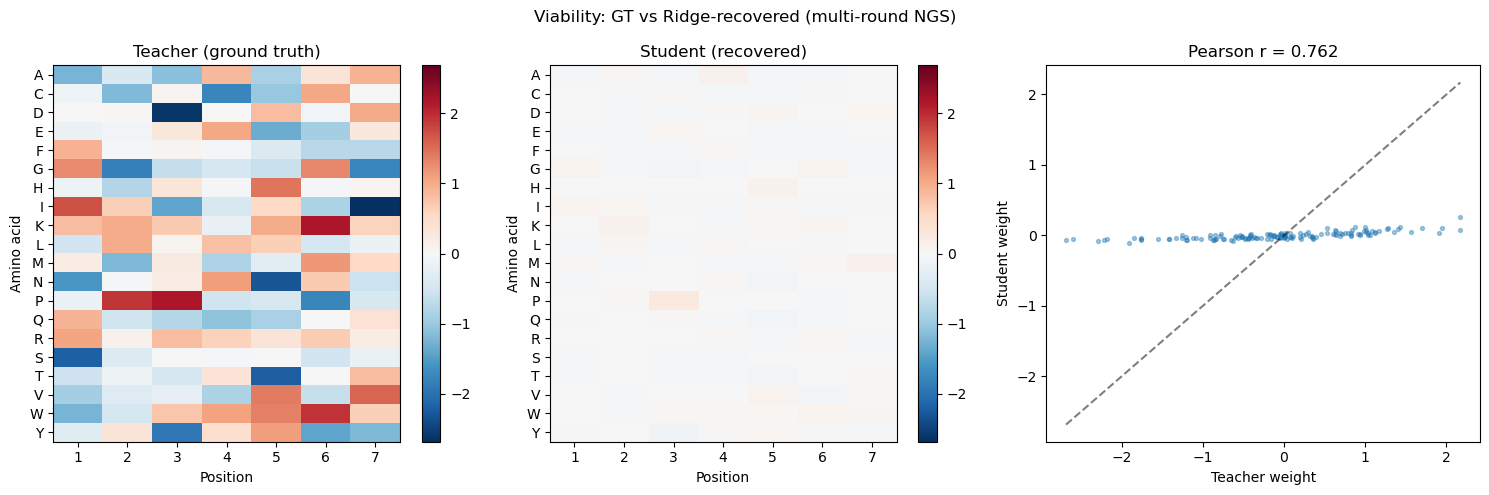

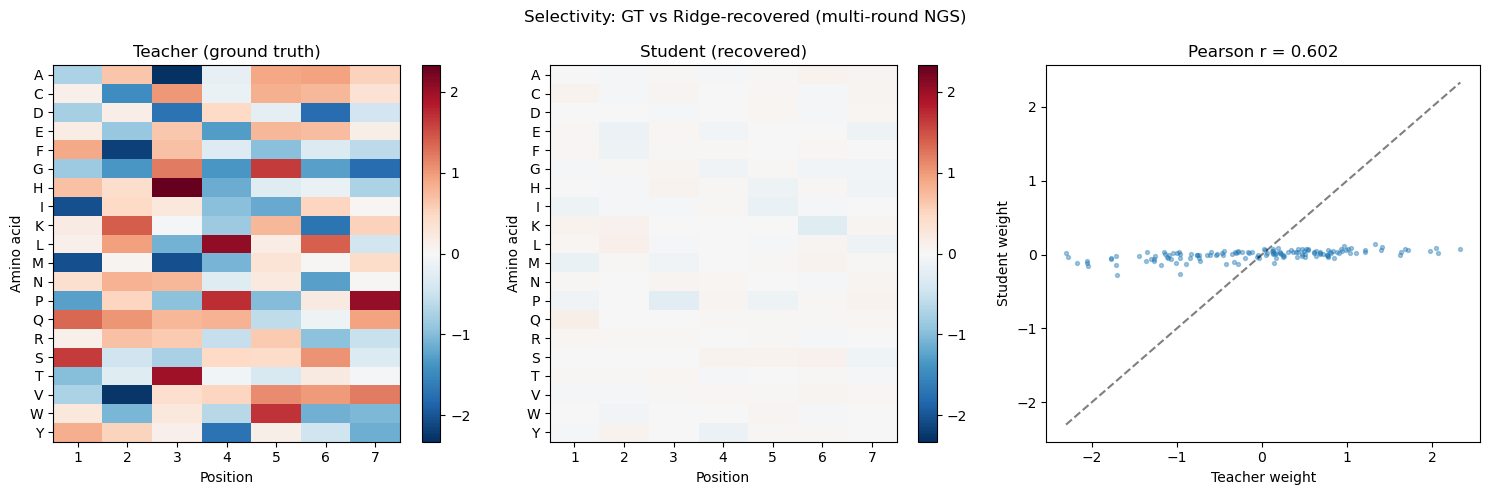

In [13]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat, title="Viability: GT vs Ridge-recovered (multi-round NGS)")
_ = plot_teacher_vs_student(F_sel, F_sel_hat, title="Selectivity: GT vs Ridge-recovered (multi-round NGS)")

In [ ]:
key_reg = jax.random.key(123)
key_reg, k_seq_reg = jax.random.split(key_reg)
N_reg = 200000
sequences_reg = jax.random.randint(k_seq_reg, shape=(N_reg, 7), minval=0, maxval=20)

protocol_reg = ProtocolV2(
    N0=100_000_000, N1=1_000_000, dilution_factor=100, sequences=sequences_reg, D=100_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat, info = reg.recover_weights_from_NGS(
    protocol_reg, n_rounds=1, k_folds=5,
)

results = reg.evaluate_recovery(protocol_reg, F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat)
print()
print(f"n_obs_viab = {info['n_obs_viab']}   n_obs_sel = {info['n_obs_sel']}")
print(f"best lambda (viab) = {info['lam_viab']:.3f}   best lambda (sel) = {info['lam_sel']:.3f}")
print()
for key, val in results.items():
    print(f'  {key:20s} : {val:.4f}')

Directed evolution rounds:   0%|          | 0/3 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

...

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

Viability   dataset: 2406 observed (sequence, round) pairs over 3 rounds
Selectivity dataset: 684 observed (sequence, round) pairs over 3 rounds
Best lambda (viability)   : 37.2759
Best lambda (selectivity) : 0.1000

n_obs_viab = 2406   n_obs_sel = 684
best lambda (viab) = 37.276   best lambda (sel) = 0.100

  r_viab_scores        : 0.7050
  r_sel_scores         : 0.8084
  r_viab_weights       : 0.8863
  r_sel_weights        : 0.8940
  precision_at_1pct    : 0.2000
  precision_at_10pct   : 0.4100


## 7. Weight recovery : impact of pressure for viability and selectivity phase

First only on Viability

In [ ]:
key_reg = jax.random.key(123)
key_reg, k_seq_reg = jax.random.split(key_reg)
N_reg = 2000
sequences_reg = jax.random.randint(k_seq_reg, shape=(N_reg, 7), minval=0, maxval=20)

####################################################################################
####################################################################################
new_T_viab = 10
new_T_sel  = 10
####################################################################################
####################################################################################

protocol_reg = ProtocolV2(
    N0=100_000_000, N1=10_000_000, dilution_factor=10, sequences=sequences_reg, D=100_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1, T_viab=new_T_viab
)

F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat, info = reg.recover_weights_from_NGS(
    protocol_reg, n_rounds=1, k_folds=3,
)

results = reg.evaluate_recovery(protocol_reg, F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat)
print()
print(f"n_obs_viab = {info['n_obs_viab']}   n_obs_sel = {info['n_obs_sel']}")
print(f"best lambda (viab) = {info['lam_viab']:.3f}   best lambda (sel) = {info['lam_sel']:.3f}")
print()
for key, val in results.items():
    print(f'  {key:20s} : {val:.4f}')

In [ ]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat, title="Viability: GT vs Ridge-recovered (Pressure on viability)")
_ = plot_teacher_vs_student(F_sel, F_sel_hat, title="Selectivity: GT vs Ridge-recovered (Pressure on viability)")

Then on selectivity

In [ ]:
protocol_reg = ProtocolV2(
    N0=100_000_000, N1=10_000_000, dilution_factor=10, sequences=sequences_reg, D=100_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1, T_sel=new_T_sel
)

F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat, info = reg.recover_weights_from_NGS(
    protocol_reg, n_rounds=1, k_folds=3,
)

results = reg.evaluate_recovery(protocol_reg, F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat)
print()
print(f"n_obs_viab = {info['n_obs_viab']}   n_obs_sel = {info['n_obs_sel']}")
print(f"best lambda (viab) = {info['lam_viab']:.3f}   best lambda (sel) = {info['lam_sel']:.3f}")
print()
for key, val in results.items():
    print(f'  {key:20s} : {val:.4f}')

In [ ]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat, title="Viability: GT vs Ridge-recovered (Pressure on sel)")
_ = plot_teacher_vs_student(F_sel, F_sel_hat, title="Selectivity: GT vs Ridge-recovered (Pressure on sel)")

Finally on both

In [ ]:
protocol_reg = ProtocolV2(
    N0=100_000_000, N1=10_000_000, dilution_factor=10, sequences=sequences_reg, D=100_000_000,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1, T_viab=new_T_viab, T_sel=new_T_sel
)

F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat, info = reg.recover_weights_from_NGS(
    protocol_reg, n_rounds=1, k_folds=3,
)

results = reg.evaluate_recovery(protocol_reg, F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat)
print()
print(f"n_obs_viab = {info['n_obs_viab']}   n_obs_sel = {info['n_obs_sel']}")
print(f"best lambda (viab) = {info['lam_viab']:.3f}   best lambda (sel) = {info['lam_sel']:.3f}")
print()
for key, val in results.items():
    print(f'  {key:20s} : {val:.4f}')

In [ ]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat, title="Viability: GT vs Ridge-recovered (Pressure on both)")
_ = plot_teacher_vs_student(F_sel, F_sel_hat, title="Selectivity: GT vs Ridge-recovered (Pressure on both)")

## 8. Weights recovery : impact of using parallel loop

In [ ]:
key_reg = jax.random.key(123)
key_reg, k_seq_reg = jax.random.split(key_reg)
N_reg = 1_000_000
N_split = 5
sequences_reg = jax.random.randint(k_seq_reg, shape=(N_reg, 7), minval=0, maxval=20)

sequences_reg_split = jnp.split(sequences_reg, N_split)
F_viab_hat_list, J_viab_hat_list, F_sel_hat_list, J_sel_hat_list, info_list = [], [], [], [], []

for i in range(N_split):
    protocol_reg = ProtocolV2(
        N0=100_000_000, N1=10_000_000, dilution_factor=10, sequences=sequences_reg_split[i], D=100_000_000,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
        noise_viab=0.1, noise_sel=0.1,
    )

    F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat, info = reg.recover_weights_from_NGS(
        protocol_reg, n_rounds=1, k_folds=3,
    )
    F_viab_hat_list.append(F_viab_hat)
    J_viab_hat_list.append(J_viab_hat)
    F_sel_hat_list.append(F_sel_hat_list)
    J_sel_hat_list.append(J_sel_hat)
    info_list.append(info)

F_viab_hat_list = jnp.array(F_viab_hat_list)
J_viab_hat_list = jnp.array(J_viab_hat_list)
F_sel_hat_list  = jnp.array(F_sel_hat_list)
J_sel_hat_list  = jnp.array(J_sel_hat_list)

F_viab_hat_avg = jnp.mean(F_viab_hat_list)
J_viab_hat_avg = jnp.mean(J_viab_hat_list)
F_sel_hat_avg  = jnp.mean(F_sel_hat_list)
J_sel_hat_avg  = jnp.mean(J_sel_hat_list)

results = reg.evaluate_recovery(protocol_reg, F_viab_hat_avg, J_viab_hat_avg, F_sel_hat_avg, J_sel_hat_avg)

for i in range(N_split):
    print()
    print(f"n_obs_viab = {info_list[i]['n_obs_viab']}   n_obs_sel = {info_list[i]['n_obs_sel']}")
    print(f"best lambda (viab) = {info_list[i]['lam_viab']:.3f}   best lambda (sel) = {info_list[i]['lam_sel']:.3f}")

print()
for key, val in results.items():
    print(f'  {key:20s} : {val:.4f}')

In [ ]:
_ = plot_teacher_vs_student(F_viab, F_viab_hat_avg, title="Viability: GT vs Ridge-recovered (Parallel loops)")
_ = plot_teacher_vs_student(F_sel, F_sel_hat_avg, title="Selectivity: GT vs Ridge-recovered (Parallel loops)")

## 9. Weights recovery : Impact of the NGS's depth

In [ ]:
D_values = [1e3, 1e5, 1e7, 1e9, 1e11, 1e13]

for D in D_values:
    print(D)
    protocol_reg = ProtocolV2(
        N0=100_000_000, N1=10_000_000, dilution_factor=10, sequences=sequences_reg, D=D,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
        noise_viab=0.1, noise_sel=0.1, T_viab=new_T_viab, T_sel=new_T_sel
    )

    F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat, info = reg.recover_weights_from_NGS(
        protocol_reg, n_rounds=1, k_folds=3,
    )

    results = reg.evaluate_recovery(protocol_reg, F_viab_hat, J_viab_hat, F_sel_hat, J_sel_hat)
    print()
    print(f"n_obs_viab = {info['n_obs_viab']}   n_obs_sel = {info['n_obs_sel']}")
    print(f"best lambda (viab) = {info['lam_viab']:.3f}   best lambda (sel) = {info['lam_sel']:.3f}")
    print()
    for key, val in results.items():
        print(f'  {key:20s} : {val:.4f}')
    _ = plot_teacher_vs_student(F_viab, F_viab_hat, title=f"Viability: GT vs Ridge-recovered (D = {D})")
    _ = plot_teacher_vs_student(F_sel, F_sel_hat, title="Selectivity: GT vs Ridge-recovered (D = {D})")

## 10. Weights recovery : Impact of noise

We will do this part after finding which of the previous parameters are optimals.

# NEXT PART : Variants recovery

The question here is which value for the parameters is optimal to keep the best theoretical variants.